In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# higher-res plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [12]:
from transformers import GPT2Model,GPT2Tokenizer
gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizerG = GPT2Tokenizer.from_pretrained('gpt2')

# get the Word Token Embeddings matrix
embeddings = gpt2.wte.weight.detach().numpy()

from transformers import BertTokenizer, BertModel
tokenizerB = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')

In [13]:
# Note - Including one more number than what I want, because arange doesn't print the last number
one_to_nine = np.arange(0,10)
ten_to_ninety = np.arange(10, 91, 10)
hundred_to_thousand = np.arange(100, 1001, 100)

print(one_to_nine)
print(ten_to_ninety)
print(hundred_to_thousand)

all_numbers = np.concat([one_to_nine, ten_to_ninety, hundred_to_thousand])

print(all_numbers)

number_tokens = [tokenizerG(str(number))['input_ids'] for number in all_numbers]

print(number_tokens)



[0 1 2 3 4 5 6 7 8 9]
[10 20 30 40 50 60 70 80 90]
[ 100  200  300  400  500  600  700  800  900 1000]
[   0    1    2    3    4    5    6    7    8    9   10   20   30   40
   50   60   70   80   90  100  200  300  400  500  600  700  800  900
 1000]
[[15], [16], [17], [18], [19], [20], [21], [22], [23], [24], [940], [1238], [1270], [1821], [1120], [1899], [2154], [1795], [3829], [3064], [2167], [6200], [7029], [4059], [8054], [9879], [7410], [12865], [12825]]


Text(0, 0.5, 'Tokens')

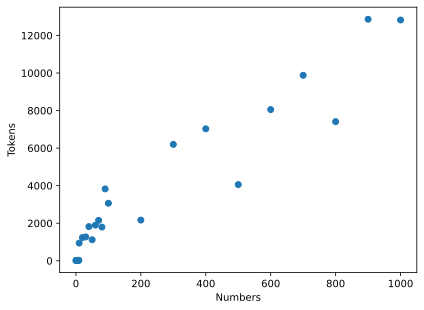

In [14]:
plt.scatter(all_numbers, number_tokens)
plt.xlabel("Numbers")
plt.ylabel("Tokens")


In [15]:
eq = '5 x 3 ='
tokens = tokenizerG.encode(eq)

print(f'{eq} -> {tokens}')
print(f'Product of tokens = {np.prod(tokens)}')
print(f'   which is {tokenizerG.decode(str(np.prod(tokens)))}')

5 x 3 = -> [20, 2124, 513, 796]
Product of tokens = 17346623040
   which is "($%''#$!%!


In [27]:

def embed(token):
    token_idx = tokenizerG.encode(token)[0]
    token_embeddings = embeddings[token_idx]

    return token_embeddings 

def unembed(token_embeddings):
    logits = token_embeddings @ embeddingsG.T
    predicted_token_idx = logits.argmax()
    predicted_token = tokenizerG.decode([predicted_token_idx])

    return predicted_token

emb_5 = embed('5')
emb_3 = embed('3')

emb_sum = emb_3 + emb_5 
emb_prod = emb_3 * emb_5

unembed_sum = unembed(emb_sum)
unembed_prod = unembed(emb_prod)

# print("Embeddings: ", emb_5)

print("Unembed: ", unembed_sum)
print("Product: ", unembed_prod)


Unembed:  5
Product:   Weinstein
